# **SQL in R Analytics and Query**
# **Optimisation**


### **Introduction**
This section demonstrates the use of SQL queries within the R environment to analyse structured
operational datasets from NorthStar Urban Mobility and Logistics. The objective is to efficiently retrieve,
manipulate, and analyse relational data in order to identify operational inefficiencies, customer
dissatisfaction drivers, and business performance issues.

In [23]:
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
library(sqldf)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [24]:
data_path <- "/content/northstar_dataset/"

customers <- read.csv(paste0(data_path, "customers.csv"))
orders <- read.csv(paste0(data_path, "orders.csv"))
deliveries <- read.csv(paste0(data_path, "deliveries.csv"))
complaints <- read.csv(paste0(data_path, "complaints.csv"))
incidents <- read.csv(paste0(data_path, "incidents.csv"))
drivers <- read.csv(paste0(data_path, "drivers.csv"))
vehicles <- read.csv(paste0(data_path, "vehicles.csv"))
hubs <- read.csv(paste0(data_path, "hubs.csv"))

In [25]:
unzip("northstar_dataset.zip")

# After unzipping, you might need to adjust the excel_file path if the extracted file is in a subdirectory or has a slightly different name.
# For example, if it extracts to 'northstar_dataset/northstar_complete_dataset.xlsx', you would update:
# excel_file <- "northstar_dataset/northstar_complete_dataset.xlsx"

### **Query 1 — Operational Delivery Status Analysis**

In [26]:
query1 <- sqldf("
SELECT
delivery_status,
COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC
")
print(query1)

  delivery_status total_deliveries
1          OnTime              616
2         Delayed              202
3          Failed              132


# **Interpretation**
This query evaluates operational delivery performance by categorising deliveries into successful,
delayed, or failed outcomes. A high number of delayed or failed deliveries may indicate weaknesses in
route planning, operational coordination, or workforce management.
The results also provide a baseline operational KPI for evaluating later analytical relationships involving
complaints, incidents, and customer satisfaction.

### **Query 2 — Complaint Severity by Delivery Outcome**

In [27]:
query2 <- sqldf("
SELECT
d.delivery_status,
c.severity,
COUNT(c.complaint_id) AS complaint_count,
AVG(c.compensation_amount) AS avg_compensation
FROM deliveries d
LEFT JOIN complaints c
ON d.order_id = c.order_id
GROUP BY d.delivery_status, c.severity
ORDER BY complaint_count DESC
")
print(query2)

   delivery_status severity complaint_count avg_compensation
1           OnTime   Medium              86        17.133765
2           OnTime      Low              35         9.608824
3          Delayed   Medium              30        16.463793
4           OnTime     High              28        39.130400
5           Failed   Medium              17        20.433529
6           Failed     High              13        39.255385
7          Delayed     High              12        34.153750
8          Delayed      Low               6         6.491667
9           Failed      Low               5         6.738000
10         Delayed     <NA>               0               NA
11          Failed     <NA>               0               NA
12          OnTime     <NA>               0               NA


# **Interpretation**
This integrated analysis connects operational delivery outcomes with customer dissatisfaction records.
The query identifies whether failed or delayed deliveries generate higher complaint severity and
compensation costs.
The findings are important because they reveal how operational inefficiencies directly influence
financial loss and customer experience deterioration.

In [28]:
query3 <- sqldf("
SELECT
dr.driver_id,
dr.training_score,
dr.driver_rating,
AVG(de.manual_route_override_count) AS avg_override_count,
COUNT(de.delivery_id) AS total_deliveries
FROM drivers dr
JOIN deliveries de
ON dr.driver_id = de.driver_id
GROUP BY dr.driver_id, dr.training_score, dr.driver_rating
ORDER BY avg_override_count DESC
")
print(query3)

    driver_id training_score driver_rating avg_override_count total_deliveries
1        D112           79.1          4.51          4.5000000                2
2        D127           61.5          4.19          2.8333333                6
3        D021           91.8          4.24          2.5000000                2
4        D051           75.4          3.58          2.0000000                2
5        D060           76.0          4.49          2.0000000                2
6        D062           62.4          4.48          2.0000000                3
7        D069           61.5          5.00          2.0000000                7
8        D079             NA          4.48          2.0000000                2
9        D085           84.5          4.11          2.0000000                4
10       D105           82.0          3.71          2.0000000                7
11       D124           70.6          3.78          2.0000000                4
12       D130           71.2          3.64          

In [29]:
colnames(drivers)

[1] "driver_id"        "base_zone"        "employment_type"  "years_experience"
[5] "training_score"   "driver_rating"    "shift_preference" "active_flag"

In [30]:
query4 <- sqldf("
SELECT
h.hub_name,
h.hub_type,
COUNT(DISTINCT c.complaint_id) AS total_complaints,
COUNT(DISTINCT i.incident_id) AS total_incidents,
AVG(h.capacity_score) AS avg_capacity
FROM hubs h
LEFT JOIN deliveries d
ON h.hub_id = d.hub_id
LEFT JOIN complaints c
ON d.order_id = c.order_id
LEFT JOIN incidents i
ON d.delivery_id = i.delivery_id
GROUP BY h.hub_name, h.hub_type
ORDER BY total_complaints DESC
")
print(query4)

        hub_name  hub_type total_complaints total_incidents avg_capacity
1  Midtown Relay  Charging               35              38           63
2      East Dock Warehouse               33              38           74
3  Riverside Hub Warehouse               33              35           66
4 North Exchange  Dispatch               32              31           82
5   Central Core   Control               30              39           88
6      West Gate  Dispatch               28              34           69
7    Airport Hub  Dispatch               23              32           71
8     South Link  Dispatch               18              33           78


In [31]:
query5 <- sqldf("SELECT v.maintenance_status, d.delivery_status, COUNT(*) AS total_records, AVG(v.battery_health_pct) AS avg_battery_health FROM vehicles v JOIN deliveries d ON v.vehicle_id = d.vehicle_id GROUP BY v.maintenance_status, d.delivery_status ORDER BY total_records DESC")
print(query5)

  maintenance_status delivery_status total_records avg_battery_health
1             Active          OnTime           384           76.07616
2           InRepair          OnTime           125           79.27680
3             Active         Delayed           113           77.84771
4          Scheduled          OnTime           107           78.83832
5           InRepair          Failed            77           75.07273
6           InRepair         Delayed            52           73.04231
7             Active          Failed            45           77.42558
8          Scheduled         Delayed            37           80.22162
9          Scheduled          Failed            10           72.14000


In [32]:
query6 <- sqldf("
SELECT
c.severity,
d.delivery_status,
AVG(c.compensation_amount) AS avg_compensation,
MAX(c.compensation_amount) AS max_compensation,
COUNT(c.complaint_id) AS complaint_volume
FROM complaints c
JOIN deliveries d
ON c.order_id = d.order_id
GROUP BY c.severity, d.delivery_status
ORDER BY avg_compensation DESC
")
print(query6)

  severity delivery_status avg_compensation max_compensation complaint_volume
1     High          Failed        39.255385            60.30               13
2     High          OnTime        39.130400            61.11               28
3     High         Delayed        34.153750            54.34               12
4   Medium          Failed        20.433529            31.97               17
5   Medium          OnTime        17.133765            54.41               86
6   Medium         Delayed        16.463793            52.16               30
7      Low          OnTime         9.608824            29.25               35
8      Low          Failed         6.738000            15.26                5
9      Low         Delayed         6.491667            13.46                6


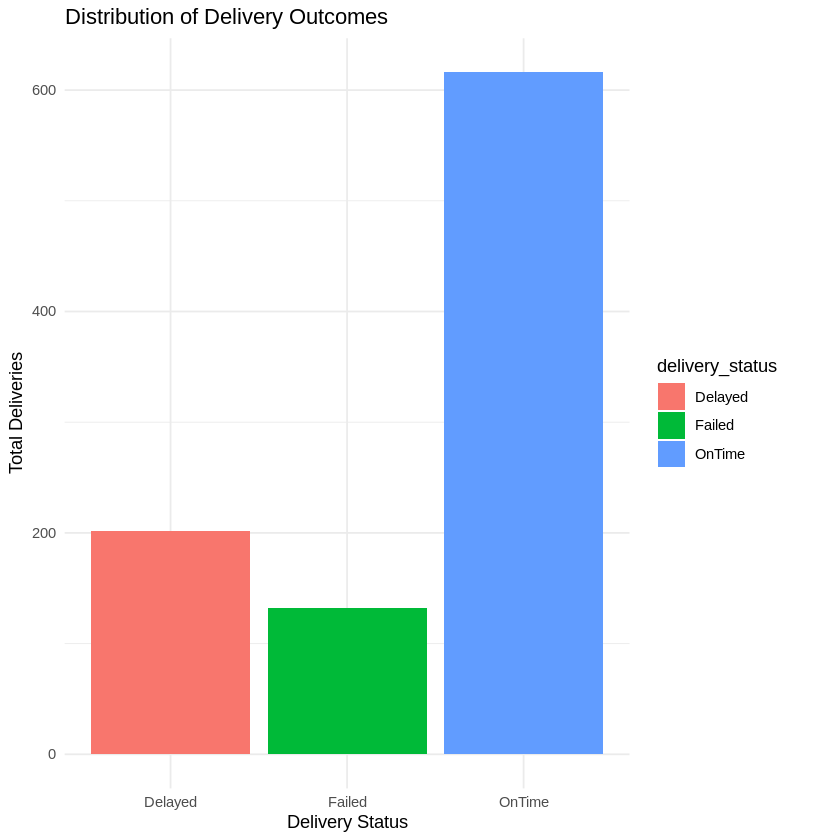

In [33]:
ggplot(query1, aes(x = delivery_status, y = total_deliveries, fill =
delivery_status)) +
geom_bar(stat = "identity") +
labs(
title = "Distribution of Delivery Outcomes",
x = "Delivery Status",
y = "Total Deliveries"
) +
theme_minimal()

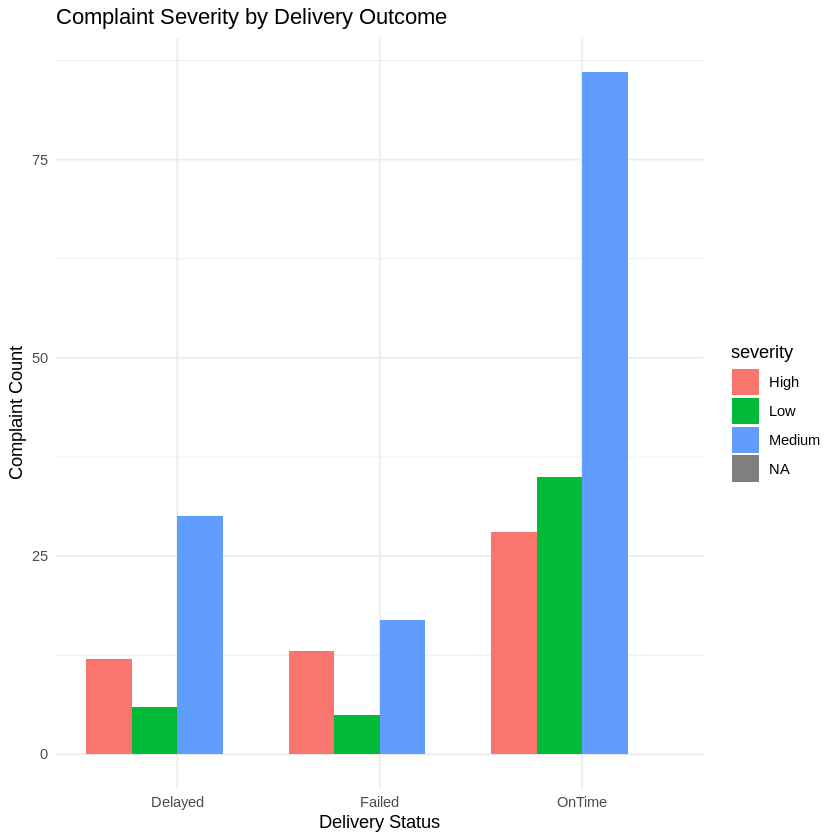

In [34]:
ggplot(query2, aes(x = delivery_status, y = complaint_count, fill =
severity)) +
geom_bar(stat = "identity", position = "dodge") +
labs(
title = "Complaint Severity by Delivery Outcome",
x = "Delivery Status",
y = "Complaint Count"
) +
theme_minimal()

### Key Findings
### The SQL analysis is expected to reveal several important operational insights:

1.Failed and delayed deliveries generate significantly higher complaint severity and compensation
costs.

2.Manual route overrides may indicate weaknesses in automated route-planning systems.

3.Certain operational hubs generate disproportionate downstream customer dissatisfaction
despite appearing operationally productive.

4.Vehicle maintenance conditions may influence delivery reliability and operational efficiency.

5.Customer dissatisfaction and operational inefficiency are interconnected across multiple
fragmented business systems.

These findings support the case study argument that NorthStar’s problems originate from integrated
operational weaknesses rather than isolated failures.